In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("titanic_dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    str    
 2   Pclass       891 non-null    str    
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(3), str(7)
memory usage: 125.5 KB


---

**Module 05**

## **Feature Engineering**

In [3]:
df.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [4]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [5]:
# df.drop(["Cabin"], axis=1, inplace=True)
# df

### **Feauture and Target Spliting**

In [6]:
X = df.drop(["Survived"], axis=1)
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,NaN,S
887,first,female,19.0,0,0,30.0000,B42,S
888,third,female,NaN,1,2,23.4500,NaN,S
889,first,male,26.0,0,0,30.0000,C148,C


In [7]:
y = df["Survived"]
y

0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: str

---

## **Train Test Split**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

In [9]:
display(X_train)
y_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.5,0,0,28.5000,C124,S
733,second,male,23.0,0,0,13.0000,NaN,S
382,third,male,32.0,0,0,7.9250,NaN,S
704,third,male,26.0,1,0,7.8542,NaN,S
813,third,female,6.0,4,2,31.2750,NaN,S
...,...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,NaN,S
270,first,male,NaN,0,0,31.0000,NaN,S
860,third,male,41.0,2,0,14.1083,NaN,S
435,first,female,14.0,1,2,120.0000,B96 B98,S


331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: str

In [10]:
display(X_test)
y_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,NaN,1,1,15.2458,NaN,C
439,second,male,31.0,0,0,10.5000,NaN,S
840,third,male,20.0,0,0,7.9250,NaN,S
720,second,female,6.0,0,1,33.0000,NaN,S
39,third,female,14.0,1,0,11.2417,NaN,C
...,...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,NaN,S
773,third,male,NaN,0,0,7.2250,NaN,C
25,third,female,38.0,1,5,31.3875,NaN,S
84,second,female,17.0,0,0,10.5000,NaN,S


709    yes
439     no
840     no
720    yes
39     yes
      ... 
433     no
773     no
25     yes
84     yes
10     yes
Name: Survived, Length: 179, dtype: str

---

## **Imputation of Missing Numerical Values**

Using Pandas DataFrame.fillna() method (Not used in ML Ecosystem)

In [11]:
X_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

In [12]:
X_test.isnull().sum()

Pclass        0
Sex           0
Age          37
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

In [13]:
# mean impute
age_mean = X_train["Age"].mean()
X_train["age mean imputor"] = X_train["Age"].fillna(age_mean)
X_test["age mean imputor"] = X_test["Age"].fillna(age_mean)

In [14]:
# median impute
age_median = X_train["Age"].median()
X_train["age median imputor"] = X_train["Age"].fillna(age_median)
X_test["age median imputor"] = X_test["Age"].fillna(age_median)

In [15]:
display(X_train.head(3))
X_test.head(3)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age mean imputor,age median imputor
331,first,male,45.5,0,0,28.500,C124,S,45.5,45.5
733,second,male,23.0,0,0,13.000,NaN,S,23.0,23.0
382,third,male,32.0,0,0,7.925,NaN,S,32.0,32.0


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age mean imputor,age median imputor
709,third,male,NaN,1,1,15.2458,NaN,C,29.498846,28.0
439,second,male,31.0,0,0,10.5000,NaN,S,31.000000,31.0
840,third,male,20.0,0,0,7.9250,NaN,S,20.000000,20.0


<Axes: xlabel='age mean imputor', ylabel='Density'>

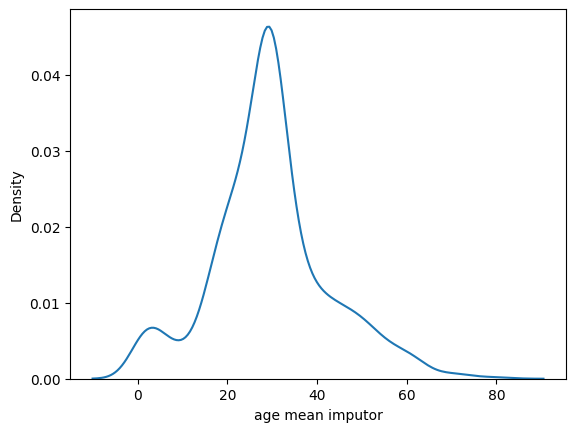

In [16]:
sns.kdeplot(x=X_train["age mean imputor"])

<Axes: xlabel='age median imputor', ylabel='Density'>

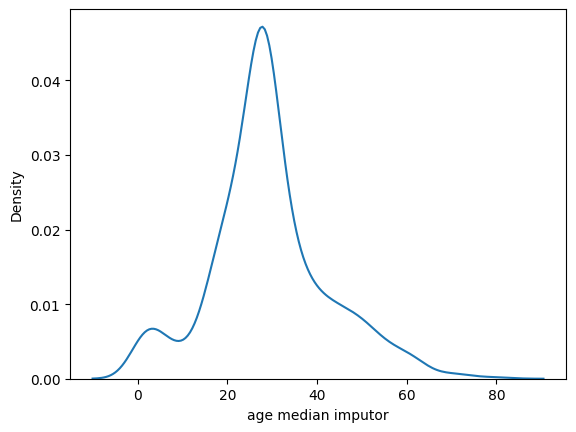

In [17]:
sns.kdeplot(x=X_train["age median imputor"])

Using SimpleImputer() class from sklearn.impute (Used in ML Ecosystem and Industry)

In [18]:
X_train.drop(["age mean imputor","age median imputor"], axis=1, inplace=True)
X_test.drop(["age mean imputor","age median imputor"], axis=1, inplace=True)

In [19]:
from sklearn.impute import SimpleImputer

In [20]:
age_imputer = SimpleImputer(missing_values = np.nan, strategy = "mean")

age_imputer.fit(X_train[["Age"]])
X_train["Age"] = age_imputer.transform(X_train[["Age"]]).ravel()

In [21]:
display(X_train.isnull().sum())
X_train.head()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.5,0,0,28.5000,C124,S
733,second,male,23.0,0,0,13.0000,NaN,S
382,third,male,32.0,0,0,7.9250,NaN,S
704,third,male,26.0,1,0,7.8542,NaN,S
813,third,female,6.0,4,2,31.2750,NaN,S


In [22]:
X_test["Age"] = age_imputer.transform(X_test[["Age"]]).ravel()

In [23]:
display(X_test.isnull().sum())
X_test.head()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,29.498846,1,1,15.2458,NaN,C
439,second,male,31.000000,0,0,10.5000,NaN,S
840,third,male,20.000000,0,0,7.9250,NaN,S
720,second,female,6.000000,0,1,33.0000,NaN,S
39,third,female,14.000000,1,0,11.2417,NaN,C


---

## **Imputation of Missing Categorical Values**

Imputing by Mode Value

In [24]:
embarked_imputer = SimpleImputer(missing_values = np.nan, strategy = "most_frequent")
embarked_imputer.fit(X_train[["Embarked"]])

X_train["Embarked"] = embarked_imputer.transform(X_train[["Embarked"]]).ravel()
X_test["Embarked"] = embarked_imputer.transform(X_test[["Embarked"]]).ravel()

In [25]:
display(X_train.isnull().sum())
X_train.head()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      0
dtype: int64

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.5,0,0,28.5000,C124,S
733,second,male,23.0,0,0,13.0000,NaN,S
382,third,male,32.0,0,0,7.9250,NaN,S
704,third,male,26.0,1,0,7.8542,NaN,S
813,third,female,6.0,4,2,31.2750,NaN,S


In [26]:
display(X_test.isnull().sum())
X_test.head()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       134
Embarked      0
dtype: int64

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,29.498846,1,1,15.2458,NaN,C
439,second,male,31.000000,0,0,10.5000,NaN,S
840,third,male,20.000000,0,0,7.9250,NaN,S
720,second,female,6.000000,0,1,33.0000,NaN,S
39,third,female,14.000000,1,0,11.2417,NaN,C


Imputing by "Missing" or "Unknown" Value

<Axes: xlabel='Cabin', ylabel='count'>

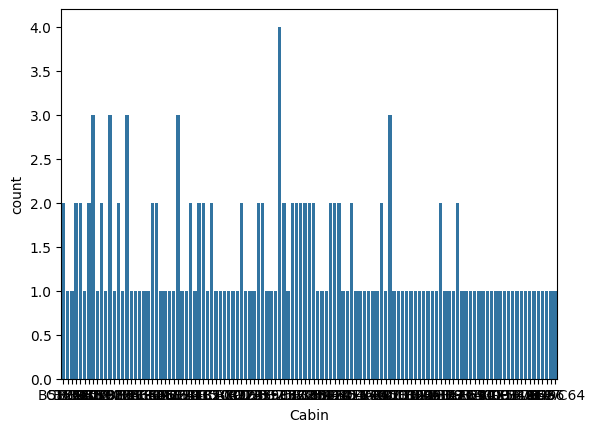

In [27]:
sns.countplot(x=X_train["Cabin"])

In [28]:
cabin_imputer = SimpleImputer(missing_values = np.nan, strategy = "constant", fill_value = "Missing", add_indicator = True) # Adds indicator for imputed values that  were missing
cabin_imputer.fit(X_train[["Cabin"]])

X_train[["Cabin","cabin_missing_indicator"]] = cabin_imputer.transform(X_train[["Cabin"]])
X_test[["Cabin","cabin_missing_indicator"]] = cabin_imputer.transform(X_test[["Cabin"]])

In [29]:
display(X_train.isnull().sum())
X_train.sample(5)

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
cabin_missing_indicator    0
dtype: int64

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
883,second,male,28.0,0,0,10.50,Missing,S,True
293,third,female,24.0,0,0,8.85,Missing,S,True
526,second,female,50.0,0,0,10.50,Missing,S,True
759,first,female,33.0,0,0,86.50,B77,S,False
683,third,male,14.0,5,2,46.90,Missing,S,True


In [30]:
display(X_test.isnull().sum())
X_test.sample(5)

Pclass                     0
Sex                        0
Age                        0
SibSp                      0
Parch                      0
Fare                       0
Cabin                      0
Embarked                   0
cabin_missing_indicator    0
dtype: int64

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
244,third,male,30.0,0,0,7.2250,Missing,C,True
688,third,male,18.0,0,0,7.7958,Missing,S,True
396,third,female,31.0,0,0,7.8542,Missing,S,True
442,third,male,25.0,1,0,7.7750,Missing,S,True
96,first,male,71.0,0,0,34.6542,A5,C,False


---
---

**Module 07**

## **Outlier Detection**

In [31]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,NaN,S
887,yes,first,female,19.0,0,0,30.0000,B42,S
888,no,third,female,NaN,1,2,23.4500,NaN,S
889,yes,first,male,26.0,0,0,30.0000,C148,C


In [32]:
df.describe()

,Age,SibSp,Parch,Fare
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,0.523008,0.381594,32.204208
std,14.526497,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


### **Z-score**

In [33]:
mean_of_age = X_train["Age"].mean()
std_of_age = X_train["Age"].std()

X_train["Zscore_Age"] = (X_train["Age"] - mean_of_age) / std_of_age
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Zscore_Age
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00
...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00


In [34]:
print(len(X_train[abs(X_train["Zscore_Age"])>3]))
X_train[abs(X_train["Zscore_Age"])>3]

5


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Zscore_Age
116,third,male,70.5,0,0,7.750,Missing,Q,True,3.155317
745,first,male,70.0,1,1,71.000,B22,S,False,3.116839
630,first,male,80.0,0,0,30.000,A23,S,False,3.886407
851,third,male,74.0,0,0,7.775,Missing,S,True,3.424666
672,second,male,70.0,0,0,10.500,Missing,S,True,3.116839


In [35]:
mean_of_fare = X_train["Fare"].mean()
std_of_fare = X_train["Fare"].std()

X_train["Zscore_Fare"] = (X_train["Fare"] - mean_of_fare) / std_of_fare
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Zscore_Age,Zscore_Fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


In [36]:
print(len(X_train[abs(X_train["Zscore_Fare"])>3]))
X_train[abs(X_train["Zscore_Fare"])>3]

17


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Zscore_Age,Zscore_Fare
118,first,male,24.000000,0,1,247.5208,B58 B60,C,False,-4.231736e-01,4.135780
716,first,female,38.000000,0,0,227.5250,C45,C,False,6.542216e-01,3.751020
377,first,male,27.000000,0,2,211.5000,C82,C,False,-1.923032e-01,3.442666
742,first,female,21.000000,2,2,262.3750,B57 B59 B63 B66,C,False,-6.540440e-01,4.421605
380,first,female,42.000000,0,0,227.5250,Missing,C,True,9.620488e-01,3.751020
779,first,female,43.000000,0,1,211.3375,B3,S,False,1.039006e+00,3.439539
730,first,female,29.000000,0,0,211.3375,B5,S,False,-3.838960e-02,3.439539
88,first,female,23.000000,3,2,263.0000,C23 C25 C27,S,False,-5.001304e-01,4.433631
341,first,female,24.000000,3,2,263.0000,C23 C25 C27,S,False,-4.231736e-01,4.433631
557,first,male,29.498846,0,0,227.5250,Missing,C,True,2.734055e-16,3.751020


### **Inter Quartile Range (IQR)**

In [37]:
q1_age = X_train["Age"].quantile(0.25)
q3_age = X_train["Age"].quantile(0.75)
IQR_age = q3_age - q1_age

lower_bound_age = q1_age - (1.5 * IQR_age)
upper_bound_age = q3_age + (1.5 * IQR_age)

print(f"Lower bound: {lower_bound_age}")
print(f"Upper bound: {upper_bound_age}")

Lower bound: 2.5
Upper bound: 54.5


In [38]:
print(len(X_train[(X_train["Age"] > upper_bound_age) | (X_train["Age"] < lower_bound_age)]))
X_train[(X_train["Age"] > upper_bound_age) | (X_train["Age"] < lower_bound_age)]

54


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Zscore_Age,Zscore_Fare
326,third,male,61.00,0,0,6.2375,Missing,S,True,2.424228,-0.507004
483,third,female,63.00,0,0,9.5875,Missing,S,True,2.578141,-0.442543
7,third,male,2.00,3,1,21.0750,Missing,S,True,-2.116223,-0.221500
305,first,male,0.92,1,2,151.5500,C22 C26,S,False,-2.199336,2.289105
829,first,female,62.00,0,0,80.0000,B28,S,False,2.501185,0.912337
626,second,male,57.00,0,0,12.3500,Missing,Q,True,2.116401,-0.389387
456,first,male,65.00,0,0,26.5500,E38,S,False,2.732055,-0.116150
172,third,female,1.00,1,1,11.1333,Missing,S,True,-2.193180,-0.412799
164,third,male,1.00,4,1,39.6875,Missing,S,True,-2.193180,0.136642
381,third,female,1.00,0,2,15.7417,Missing,C,True,-2.193180,-0.324124


In [39]:
q1_fare = X_train["Fare"].quantile(0.25)
q3_fare = X_train["Fare"].quantile(0.75)
IQR_fare = q3_fare - q1_fare

lower_bound_fare = max(0, q1_fare - (1.5 * IQR_fare)) # As fare cannot be less than 0
upper_bound_fare = q3_fare + (1.5 * IQR_fare)

print(f"Lower bound: {lower_bound_fare}")
print(f"Upper bound: {upper_bound_fare}")

Lower bound: 0
Upper bound: 64.3625


In [40]:
print(len(X_train[(X_train["Fare"] > upper_bound_fare) | (X_train["Fare"] < lower_bound_fare)]))
X_train[(X_train["Fare"] > upper_bound_fare) | (X_train["Fare"] < lower_bound_fare)]

96


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Zscore_Age,Zscore_Fare
118,first,male,24.0,0,1,247.5208,B58 B60,C,False,-0.423174,4.135780
486,first,female,35.0,1,0,90.0000,C93,S,False,0.423351,1.104757
716,first,female,38.0,0,0,227.5250,C45,C,False,0.654222,3.751020
390,first,male,36.0,1,2,120.0000,B96 B98,S,False,0.500308,1.682019
377,first,male,27.0,0,2,211.5000,C82,C,False,-0.192303,3.442666
...,...,...,...,...,...,...,...,...,...,...,...
681,first,male,27.0,0,0,76.7292,D49,C,False,-0.192303,0.849400
385,second,male,18.0,0,0,73.5000,Missing,S,True,-0.884914,0.787264
700,first,female,18.0,1,0,227.5250,C62 C64,C,False,-0.884914,3.751020
435,first,female,14.0,1,2,120.0000,B96 B98,S,False,-1.192742,1.682019


---

## **Outlier Handling**

For normal distrubution, using z-score is the most appropriate approach for detecting outliers. On the other hand, if skewness exists in data, the IQR is the correct approach.

In [41]:
X_train = X_train[abs(X_train["Zscore_Age"])<3]
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,Zscore_Age,Zscore_Fare
331,first,male,45.500000,0,0,28.5000,C124,S,False,1.231398e+00,-0.078628
733,second,male,23.000000,0,0,13.0000,Missing,S,True,-5.001304e-01,-0.376880
382,third,male,32.000000,0,0,7.9250,Missing,S,True,1.924808e-01,-0.474533
704,third,male,26.000000,1,0,7.8542,Missing,S,True,-2.692600e-01,-0.475896
813,third,female,6.000000,4,2,31.2750,Missing,S,True,-1.808396e+00,-0.025232
...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,-6.540440e-01,-0.479825
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.734055e-16,-0.030523
860,third,male,41.000000,2,0,14.1083,Missing,S,True,8.850920e-01,-0.355554
435,first,female,14.000000,1,2,120.0000,B96 B98,S,False,-1.192742e+00,1.682019


In the column 'Fare', as removing the outlier values of that column might remove necessary values of other features which might cause disruption and inappropriate learning of our model, capping them to the upper bound value measured by the IQR is the standard approach.

In [42]:
print(X_train[(X_train["Fare"]>upper_bound_fare) | (X_train["Fare"]<lower_bound_fare)]["Fare"].max())
print(upper_bound_fare)

512.3292
64.3625


In [43]:
X_train["Fare"] = X_train["Fare"].clip(lower_bound_fare, upper_bound_fare)
X_train["Fare"].max()

np.float64(64.3625)

---
---

**Module 07**

In [44]:
X_train.drop(["Zscore_Age", "Zscore_Fare"], axis=1, inplace=True)
X_train.sample(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator
826,third,male,29.498846,0,0,56.4958,Missing,S,True
593,third,female,29.498846,0,2,7.7500,Missing,Q,True
540,first,female,36.000000,0,2,64.3625,B22,S,False
513,first,female,54.000000,1,0,59.4000,Missing,C,True
257,first,female,30.000000,0,0,64.3625,B77,S,False


Ordinal Values: Pclass

Nominal Values: Sex, Embarked

## **Encoding**

**Ordinal Encoding** (Standard approach for **Ordinal Categorical** values or categorical values that follow order or precedence)

In [45]:
from sklearn.preprocessing import OrdinalEncoder

pclass_encoder = OrdinalEncoder(categories = [["third", "second", "first"]])
pclass_encoder.fit(X_train[["Pclass"]])

X_train["encoded_Pclass"] = pclass_encoder.transform(X_train[["Pclass"]]).ravel()
X_test["encoded_Pclass"] = pclass_encoder.transform(X_test[["Pclass"]]).ravel()

In [46]:
display(X_train.sample(5))
X_test.sample(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,encoded_Pclass
752,third,male,33.000000,0,0,9.500,Missing,S,True,0.0
351,first,male,29.498846,0,0,35.000,C128,S,False,2.0
19,third,female,29.498846,0,0,7.225,Missing,C,True,0.0
249,second,male,54.000000,1,0,26.000,Missing,S,True,1.0
51,third,male,21.000000,0,0,7.800,Missing,S,True,0.0


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,encoded_Pclass
485,third,female,29.498846,3,1,25.4667,Missing,S,True,0.0
44,third,female,19.000000,0,0,7.8792,Missing,Q,True,0.0
853,first,female,16.000000,0,1,39.4000,D28,S,False,2.0
231,third,male,29.000000,0,0,7.7750,Missing,S,True,0.0
139,first,male,24.000000,0,0,79.2000,B86,C,False,2.0


---

**One Hot Encoding** (Standard approach for **Nominal Categorical** values or categorical values that do not follow order or precedence)

In [47]:
from sklearn.preprocessing import OneHotEncoder

sex_ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas") # sparse_output returns compressed values if not false and transformig into pandas in set_output returns dataframe column

sex_ohe.fit(X_train[["Sex"]])
encoded_df_sex = sex_ohe.transform(X_train[["Sex"]])

X_train = pd.concat([X_train, encoded_df_sex], axis=1)
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,encoded_Pclass,Sex_female,Sex_male
331,first,male,45.500000,0,0,28.5000,C124,S,False,2.0,0.0,1.0
733,second,male,23.000000,0,0,13.0000,Missing,S,True,1.0,0.0,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0
704,third,male,26.000000,1,0,7.8542,Missing,S,True,0.0,0.0,1.0
813,third,female,6.000000,4,2,31.2750,Missing,S,True,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,0.0,1.0,0.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0,0.0,1.0
860,third,male,41.000000,2,0,14.1083,Missing,S,True,0.0,0.0,1.0
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,2.0,1.0,0.0


In [48]:
encoded_df_sex = sex_ohe.transform(X_test[["Sex"]])

X_test = pd.concat([X_test, encoded_df_sex], axis=1)
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,encoded_Pclass,Sex_female,Sex_male
709,third,male,29.498846,1,1,15.2458,Missing,C,True,0.0,0.0,1.0
439,second,male,31.000000,0,0,10.5000,Missing,S,True,1.0,0.0,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0
720,second,female,6.000000,0,1,33.0000,Missing,S,True,1.0,1.0,0.0
39,third,female,14.000000,1,0,11.2417,Missing,C,True,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True,0.0,0.0,1.0
773,third,male,29.498846,0,0,7.2250,Missing,C,True,0.0,0.0,1.0
25,third,female,38.000000,1,5,31.3875,Missing,S,True,0.0,1.0,0.0
84,second,female,17.000000,0,0,10.5000,Missing,S,True,1.0,1.0,0.0


In [49]:
embarked_ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
embarked_ohe.fit(X_train[["Embarked"]])

encoded_df_embarked = embarked_ohe.transform(X_train[["Embarked"]])

X_train = pd.concat([X_train, encoded_df_embarked], axis=1)
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
331,first,male,45.500000,0,0,28.5000,C124,S,False,2.0,0.0,1.0,0.0,0.0,1.0
733,second,male,23.000000,0,0,13.0000,Missing,S,True,1.0,0.0,1.0,0.0,0.0,1.0
382,third,male,32.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
704,third,male,26.000000,1,0,7.8542,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
813,third,female,6.000000,4,2,31.2750,Missing,S,True,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,third,female,21.000000,0,0,7.6500,Missing,S,True,0.0,1.0,0.0,0.0,0.0,1.0
270,first,male,29.498846,0,0,31.0000,Missing,S,True,2.0,0.0,1.0,0.0,0.0,1.0
860,third,male,41.000000,2,0,14.1083,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
435,first,female,14.000000,1,2,64.3625,B96 B98,S,False,2.0,1.0,0.0,0.0,0.0,1.0


In [50]:
encoded_df_embarked = embarked_ohe.transform(X_test[["Embarked"]])

X_test = pd.concat([X_test, encoded_df_embarked], axis=1)
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,cabin_missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
709,third,male,29.498846,1,1,15.2458,Missing,C,True,0.0,0.0,1.0,1.0,0.0,0.0
439,second,male,31.000000,0,0,10.5000,Missing,S,True,1.0,0.0,1.0,0.0,0.0,1.0
840,third,male,20.000000,0,0,7.9250,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
720,second,female,6.000000,0,1,33.0000,Missing,S,True,1.0,1.0,0.0,0.0,0.0,1.0
39,third,female,14.000000,1,0,11.2417,Missing,C,True,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,third,male,17.000000,0,0,7.1250,Missing,S,True,0.0,0.0,1.0,0.0,0.0,1.0
773,third,male,29.498846,0,0,7.2250,Missing,C,True,0.0,0.0,1.0,1.0,0.0,0.0
25,third,female,38.000000,1,5,31.3875,Missing,S,True,0.0,1.0,0.0,0.0,0.0,1.0
84,second,female,17.000000,0,0,10.5000,Missing,S,True,1.0,1.0,0.0,0.0,0.0,1.0


In [51]:
X_train.drop(["Pclass","Sex","Embarked"], axis=1, inplace=True)
X_test.drop(["Pclass","Sex","Embarked"], axis=1, inplace=True)

display(X_train.sample(5))
X_test.sample(5)

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
325,36.0,0,0,64.3625,C32,False,2.0,1.0,0.0,1.0,0.0,0.0
160,44.0,0,1,16.1000,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
838,32.0,0,0,56.4958,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
60,22.0,0,0,7.2292,Missing,True,0.0,0.0,1.0,1.0,0.0,0.0
91,20.0,0,0,7.8542,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0


,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
84,17.000000,0,0,10.5000,Missing,True,1.0,1.0,0.0,0.0,0.0,1.0
643,29.498846,0,0,56.4958,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
819,10.000000,3,2,27.9000,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0
572,36.000000,0,0,26.3875,E25,False,2.0,0.0,1.0,0.0,0.0,1.0
250,29.498846,0,0,7.2500,Missing,True,0.0,0.0,1.0,0.0,0.0,1.0


**Encoding the cabin column**

In [52]:
X_train["Cabin"].dtype

<StringDtype(na_value=nan)>

In [53]:
X_train["Cabin_Deck"] = X_train["Cabin"].astype(str).str[0]
X_train["Cabin_Deck"].value_counts()

Cabin_Deck
M    550
C     52
B     37
E     24
D     19
F     12
A      9
G      3
T      1
Name: count, dtype: int64

In [54]:
X_test["Cabin_Deck"] = X_test["Cabin"].astype(str).str[0]
X_test["Cabin_Deck"].value_counts()

Cabin_Deck
M    134
D     14
B      9
E      8
C      7
A      5
F      1
G      1
Name: count, dtype: int64

In [55]:
deck_ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas") # One Hot Encoder as the values in the deck are categorical although the cabins aren't

deck_ohe.fit(X_train[["Cabin_Deck"]])

encoded_deck_train = deck_ohe.transform(X_train[["Cabin_Deck"]])
X_train = pd.concat([X_train, encoded_deck_train], axis=1)
X_train.sample(5)

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,...,Cabin_Deck,Cabin_Deck_A,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
269,35.000000,0,0,64.3625,C99,False,2.0,1.0,0.0,0.0,...,C,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
497,29.498846,0,0,15.1000,Missing,True,0.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
267,25.000000,1,0,7.7750,Missing,True,0.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
430,28.000000,0,0,26.5500,C52,False,2.0,0.0,1.0,0.0,...,C,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
221,27.000000,0,0,13.0000,Missing,True,1.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [56]:
encoded_deck_test = deck_ohe.transform(X_test[["Cabin_Deck"]])
X_test = pd.concat([X_test, encoded_deck_test], axis=1)
X_test.sample(5)

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,...,Cabin_Deck,Cabin_Deck_A,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
433,17.0,0,0,7.125,Missing,True,0.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
604,35.0,0,0,26.550,Missing,True,2.0,0.0,1.0,1.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
292,36.0,0,0,12.875,D,False,1.0,0.0,1.0,1.0,...,D,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
323,22.0,1,1,29.000,Missing,True,1.0,1.0,0.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
772,57.0,0,0,10.500,E77,False,1.0,1.0,0.0,0.0,...,E,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


---

**Label Encoding** (Encoding the target column or feature)

In [57]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train)

y_train_array = le.transform(y_train)
y_test_array = le.transform(y_test)

In [58]:
print(type(y_train_array))
y_train_array

<class 'numpy.ndarray'>


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,

In [59]:
# Converting into Pandas Series

y_train = pd.Series(y_train_array, index=y_train.index, name=y_train.name)
y_test = pd.Series(y_test_array, index=y_test.index, name=y_test.name)

In [60]:
display(y_train)

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

---
---

**Module 08**

## **Scaling**

**Standard Scaling or Z-score Normalization** (For normal distribution)

<Axes: xlabel='Age', ylabel='Density'>

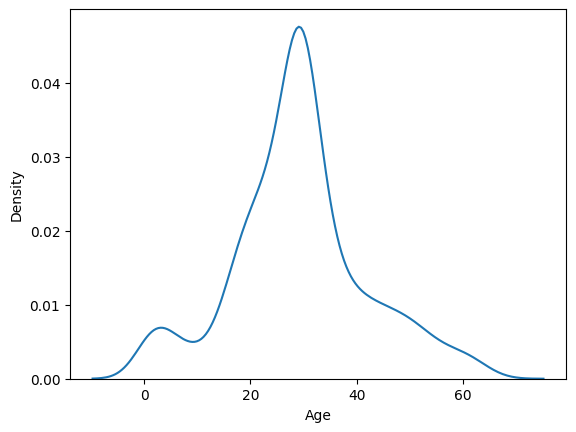

In [61]:
sns.kdeplot(X_train["Age"])

In [62]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(X_train[["Age"]])

X_train["Age"] = ss.transform(X_train[["Age"]]).ravel()
X_test["Age"] = ss.transform(X_test[["Age"]]).ravel

In [66]:
X_train

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,...,Cabin_Deck,Cabin_Deck_A,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
331,1.304495,0,0,0.442804,C124,False,2.0,0.0,1.0,0.0,...,C,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,-0.495295,0,0,0.201981,Missing,True,1.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
382,0.224621,0,0,0.123131,Missing,True,0.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
704,-0.255323,1,0,0.122031,Missing,True,0.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
813,-1.855135,4,2,0.485920,Missing,True,0.0,1.0,0.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.655276,0,0,0.118858,Missing,True,0.0,1.0,0.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,0.024552,0,0,0.481647,Missing,True,2.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,0.944537,2,0,0.219201,Missing,True,0.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
435,-1.215210,1,2,1.000000,B96 B98,False,2.0,1.0,0.0,0.0,...,B,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='Age', ylabel='Density'>

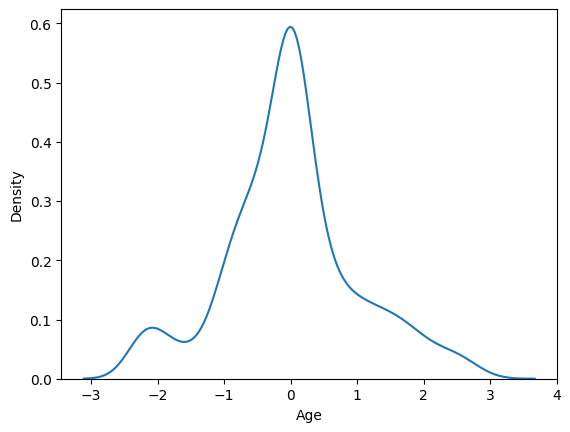

In [63]:
sns.kdeplot(X_train["Age"])

---

**MinMax Scalling** (For skewed distribution)

<Axes: xlabel='Fare', ylabel='Density'>

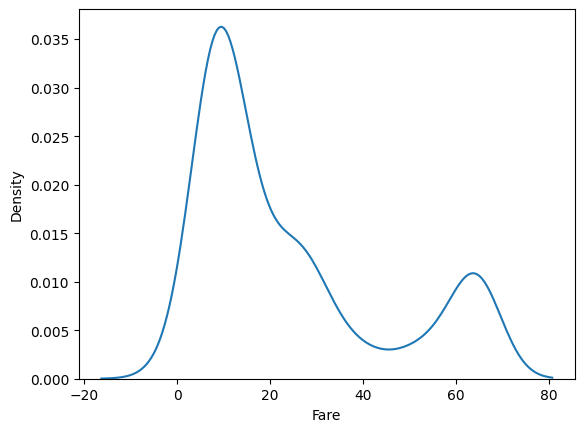

In [64]:
sns.kdeplot(X_train["Fare"])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

min_max = MinMaxScaler()
min_max.fit(X_train[["Fare"]])

X_train["Fare"] = min_max.transform(X_train[["Fare"]])
X_test["Fare"] = min_max.transform(X_test[["Fare"]])

In [67]:
X_train

,Age,SibSp,Parch,Fare,Cabin,cabin_missing_indicator,encoded_Pclass,Sex_female,Sex_male,Embarked_C,...,Cabin_Deck,Cabin_Deck_A,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_M,Cabin_Deck_T
331,1.304495,0,0,0.442804,C124,False,2.0,0.0,1.0,0.0,...,C,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
733,-0.495295,0,0,0.201981,Missing,True,1.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
382,0.224621,0,0,0.123131,Missing,True,0.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
704,-0.255323,1,0,0.122031,Missing,True,0.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
813,-1.855135,4,2,0.485920,Missing,True,0.0,1.0,0.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.655276,0,0,0.118858,Missing,True,0.0,1.0,0.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
270,0.024552,0,0,0.481647,Missing,True,2.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
860,0.944537,2,0,0.219201,Missing,True,0.0,0.0,1.0,0.0,...,M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
435,-1.215210,1,2,1.000000,B96 B98,False,2.0,1.0,0.0,0.0,...,B,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='Fare', ylabel='Density'>

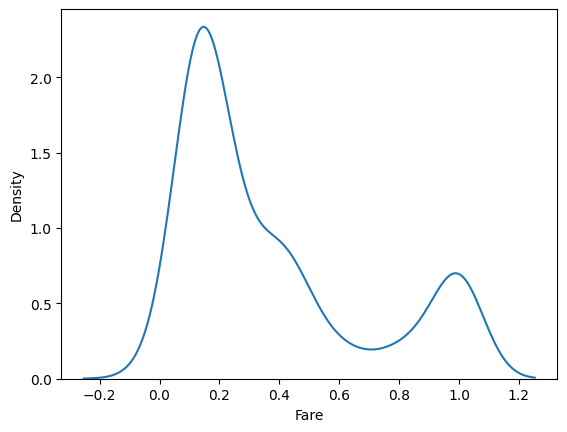

In [68]:
sns.kdeplot(X_train["Fare"])

---
---